# Universidad Nacional de Colombia

Técnicas de Optimización 2026-I

Taller 3 - Optimización metaheurística multiobjetivo

**Integrantes: David Guevara y Juan Pablo Jiménez**  


Este notebook presenta el desarrollo reproducible del Taller 3. Ejecuta NSGA-II y MOPSO para construir frentes de Pareto, calcula indicadores de calidad, consolida una matriz de decisión y selecciona una alternativa final mediante TOPSIS y suma ponderada normalizada.


## 1. Planteamiento del problema

Las variables de decisión representan la cantidad entera de escritorios metálicos a producir:

- $x_1$: escritorios básicos.
- $x_2$: escritorios estándar.
- $x_3$: escritorios premium.

El vector de decisión es:

$$
\mathbf{x} = [x_1, x_2, x_3]
$$

con límites:

$$
0 \leq x_1 \leq 60, \quad 0 \leq x_2 \leq 50, \quad 0 \leq x_3 \leq 40
$$

La producción mínima exige:

$$
x_1 + x_2 + x_3 \geq 30
$$

Las restricciones de recursos corresponden a lámina, corte, soldadura y empaque:

$$
A\mathbf{x} \leq \mathbf{b}
$$

El primer objetivo busca maximizar la ganancia:

$$
G(\mathbf{x}) = 40x_1 + 65x_2 + 90x_3
$$

El segundo objetivo busca minimizar el tiempo total:

$$
T(\mathbf{x}) = 0.8x_1 + 1.2x_2 + 1.7x_3
$$

Como los algoritmos trabajan con una formulación interna de minimización, la ganancia se transforma como:

$$
f_1(\mathbf{x}) = -G(\mathbf{x}), \quad f_2(\mathbf{x}) = T(\mathbf{x})
$$

## 2. Preparación del entorno

In [1]:
from pathlib import Path
import sys
from time import perf_counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import problema
from problema import (
    CONSUMOS_RECURSOS,
    DISPONIBILIDADES,
    GANANCIAS,
    LIMITES_INFERIORES,
    LIMITES_SUPERIORES,
    PRODUCCION_MINIMA,
    consumo_recursos,
    es_factible,
    evaluar,
    generar_solucion_factible,
    resumen_solucion,
)
from analisis import calcular_spacing, evaluar_poblacion, extraer_frente_no_dominado, porcentaje_no_dominadas
from decision import construir_matriz_decision_desde_dataframes
from frentes import consolidar_frentes_desde_corridas
from graficas import guardar_grafica_frente
from main import (
    COEFICIENTE_COGNITIVO,
    COEFICIENTE_SOCIAL,
    INERCIA_FINAL,
    INERCIA_INICIAL,
    ITERACIONES,
    PROBABILIDAD_CRUCE,
    PROBABILIDAD_MUTACION,
    SEMILLAS,
    TAMANO_POBLACION,
    TAMANO_REPOSITORIO,
    calcular_indicadores,
)
from mopso import ejecutar_mopso
from nsga2 import ejecutar_nsga2
from multicriterio import (
    PESO_GANANCIA,
    PESO_TIEMPO,
    aplicar_suma_ponderada,
    aplicar_topsis,
    construir_tabla_seleccionadas,
    normalizar_criterios,
)

CARPETA_RESULTADOS = Path("resultados")
CARPETA_RESULTADOS.mkdir(exist_ok=True)

versiones = pd.DataFrame(
    [
        {"componente": "Python", "version": sys.version.split()[0]},
        {"componente": "NumPy", "version": np.__version__},
        {"componente": "Pandas", "version": pd.__version__},
        {"componente": "Matplotlib", "version": matplotlib.__version__},
    ]
)
versiones

,componente,version
0,Python,3.13.0
1,NumPy,2.4.2
2,Pandas,3.0.0
3,Matplotlib,3.10.8


## 3. Parámetros de simulación

Los parámetros se toman de las constantes definidas en los módulos del proyecto.

In [2]:
parametros = pd.DataFrame(
    [
        {"grupo": "Común", "parametro": "Tamaño de población/enjambre", "valor": TAMANO_POBLACION},
        {"grupo": "Común", "parametro": "Iteraciones", "valor": ITERACIONES},
        {"grupo": "Común", "parametro": "Semillas", "valor": ", ".join(map(str, SEMILLAS))},
        {"grupo": "NSGA-II", "parametro": "Probabilidad de cruce", "valor": PROBABILIDAD_CRUCE},
        {"grupo": "NSGA-II", "parametro": "Probabilidad de mutación", "valor": PROBABILIDAD_MUTACION},
        {"grupo": "MOPSO", "parametro": "Inercia inicial", "valor": INERCIA_INICIAL},
        {"grupo": "MOPSO", "parametro": "Inercia final", "valor": INERCIA_FINAL},
        {"grupo": "MOPSO", "parametro": "Coeficiente cognitivo", "valor": COEFICIENTE_COGNITIVO},
        {"grupo": "MOPSO", "parametro": "Coeficiente social", "valor": COEFICIENTE_SOCIAL},
        {"grupo": "MOPSO", "parametro": "Repositorio externo máximo", "valor": TAMANO_REPOSITORIO},
        {"grupo": "Multicriterio", "parametro": "Peso ganancia", "valor": PESO_GANANCIA},
        {"grupo": "Multicriterio", "parametro": "Peso tiempo", "valor": PESO_TIEMPO},
    ]
)
parametros

,grupo,parametro,valor
0,Común,Tamaño de población/enjambre,30
1,Común,Iteraciones,100
2,Común,Semillas,"10, 20, 30, 40, 50"
3,NSGA-II,Probabilidad de cruce,0.9
4,NSGA-II,Probabilidad de mutación,0.333333
5,MOPSO,Inercia inicial,0.9
6,MOPSO,Inercia final,0.4
7,MOPSO,Coeficiente cognitivo,1.5
8,MOPSO,Coeficiente social,1.5
9,MOPSO,Repositorio externo máximo,100


## 4. Respuesta al punto 7

### 4.1 Codificación de variables enteras

Las soluciones se codifican como vectores enteros $[x_1,x_2,x_3]$. En NSGA-II los individuos se generan y operan directamente como enteros. En MOPSO las posiciones se actualizan temporalmente en continuo, pero se limitan al rango permitido y se redondean antes de evaluarse.

### 4.2 Manejo de soluciones no factibles

Las soluciones no factibles se descartan y se reemplazan por soluciones factibles generadas por las funciones del módulo `problema.py`. No se usan penalizaciones: ambos algoritmos mantienen poblaciones o enjambres evaluables respecto a límites, producción mínima y recursos.

### 4.3 Identificación de soluciones no dominadas

La dominancia se evalúa con ambos objetivos en minimización. Una solución domina a otra si no es peor en ningún objetivo y es estrictamente mejor en al menos uno. Este criterio se implementa en `analisis.py`.

### 4.4 Normalización de objetivos

Para los indicadores se usa normalización min-max sobre los objetivos. Para las técnicas multicriterio se orientan los criterios para que valores normalizados altos indiquen mejor desempeño: ganancia como beneficio y tiempo como costo.

### 4.5 Parámetros y procedencia del código

Los parámetros usados corresponden a las constantes del proyecto: población o enjambre de 30 soluciones, 100 iteraciones, semillas 10, 20, 30, 40 y 50, cruce 0.90, mutación 1/3, inercia decreciente 0.90 a 0.40, coeficientes cognitivo y social 1.50, y repositorio MOPSO máximo de 100 soluciones.

El código fue desarrollado por el grupo en Python con apoyo de ChatGPT para estructuración, revisión y explicación del código. Se mantiene la integridad académica: las implementaciones se verifican en este repositorio y no se copian resultados manuales dentro del notebook.

### 4.6 Pesos multicriterio

Se usan pesos equilibrados:

$$
w_G = 0.50, \quad w_T = 0.50
$$

Estos pesos se aplican tanto en TOPSIS como en suma ponderada normalizada.

## 5. Verificación del modelo

Se genera una solución factible mediante `problema.py` y se evalúan sus objetivos y consumos de recursos con las funciones del módulo.

In [3]:
rng_verificacion = np.random.default_rng(SEMILLAS[0])
solucion_prueba = generar_solucion_factible(rng_verificacion)
resumen = resumen_solucion(solucion_prueba)
recursos = consumo_recursos(solucion_prueba)
objetivos = evaluar(solucion_prueba)

tabla_verificacion = pd.DataFrame(
    [
        {
            "x1": int(solucion_prueba[0]),
            "x2": int(solucion_prueba[1]),
            "x3": int(solucion_prueba[2]),
            "factible": es_factible(solucion_prueba),
            "ganancia": -objetivos[0],
            "tiempo": objetivos[1],
            "lamina": recursos[0],
            "corte": recursos[1],
            "soldadura": recursos[2],
            "empaque": recursos[3],
        }
    ]
)
tabla_verificacion

,x1,x2,x3,factible,ganancia,tiempo,lamina,corte,soldadura,empaque
0,31,7,34,True,4755.0,91.0,155.7,32.85,47.2,10.95


## 6. Ejecución completa de NSGA-II y MOPSO

Se ejecutan cinco corridas por método con semillas deterministas. Los resultados quedan en memoria para reutilizarse en las secciones posteriores.

In [4]:
resultados_corridas = []
filas_indicadores = []

for numero_corrida, semilla in enumerate(SEMILLAS, start=1):
    inicio = perf_counter()
    poblacion_nsga2, frente_nsga2, objetivos_nsga2 = ejecutar_nsga2(
        tamano_poblacion=TAMANO_POBLACION,
        iteraciones=ITERACIONES,
        probabilidad_cruce=PROBABILIDAD_CRUCE,
        probabilidad_mutacion=PROBABILIDAD_MUTACION,
        semilla=semilla,
    )
    tiempo_nsga2 = perf_counter() - inicio
    porcentaje_nsga2, spacing_nsga2, cantidad_nsga2 = calcular_indicadores(poblacion_nsga2)

    inicio = perf_counter()
    enjambre_mopso, repositorio_mopso, objetivos_repositorio_mopso = ejecutar_mopso(
        tamano_enjambre=TAMANO_POBLACION,
        iteraciones=ITERACIONES,
        inercia_inicial=INERCIA_INICIAL,
        inercia_final=INERCIA_FINAL,
        coeficiente_cognitivo=COEFICIENTE_COGNITIVO,
        coeficiente_social=COEFICIENTE_SOCIAL,
        tamano_repositorio=TAMANO_REPOSITORIO,
        semilla=semilla,
    )
    tiempo_mopso = perf_counter() - inicio
    porcentaje_mopso, spacing_mopso, cantidad_mopso = calcular_indicadores(enjambre_mopso)

    resultados_corridas.append(
        {
            "corrida": numero_corrida,
            "semilla": semilla,
            "poblacion_nsga2": poblacion_nsga2,
            "frente_nsga2": frente_nsga2,
            "objetivos_nsga2": objetivos_nsga2,
            "enjambre_mopso": enjambre_mopso,
            "repositorio_mopso": repositorio_mopso,
            "objetivos_repositorio_mopso": objetivos_repositorio_mopso,
        }
    )

    filas_indicadores.extend(
        [
            {
                "metodo": "NSGA-II",
                "corrida": numero_corrida,
                "semilla": semilla,
                "soluciones_finales": len(poblacion_nsga2),
                "iteraciones": ITERACIONES,
                "soluciones_no_dominadas": cantidad_nsga2,
                "porcentaje_no_dominadas": porcentaje_nsga2,
                "spacing": spacing_nsga2,
                "tiempo_ejecucion_s": tiempo_nsga2,
            },
            {
                "metodo": "MOPSO",
                "corrida": numero_corrida,
                "semilla": semilla,
                "soluciones_finales": len(enjambre_mopso),
                "iteraciones": ITERACIONES,
                "soluciones_no_dominadas": cantidad_mopso,
                "porcentaje_no_dominadas": porcentaje_mopso,
                "spacing": spacing_mopso,
                "tiempo_ejecucion_s": tiempo_mopso,
            },
        ]
    )

tabla_corridas = pd.DataFrame(filas_indicadores)
tabla_corridas.to_csv(CARPETA_RESULTADOS / "indicadores_corridas.csv", index=False, encoding="utf-8-sig")
tabla_corridas

,metodo,corrida,semilla,soluciones_finales,iteraciones,soluciones_no_dominadas,porcentaje_no_dominadas,spacing,tiempo_ejecucion_s
0,NSGA-II,1,10,30,100,27,100.000000,0.024446,3.734128
1,MOPSO,1,10,30,100,26,86.666667,0.046138,6.725040
2,NSGA-II,2,20,30,100,27,100.000000,0.023717,3.699576
3,MOPSO,2,20,30,100,25,86.666667,0.048558,6.673211
4,NSGA-II,3,30,30,100,27,100.000000,0.027571,3.722667
5,MOPSO,3,30,30,100,28,96.666667,0.022283,6.755769
6,NSGA-II,4,40,30,100,26,100.000000,0.028207,3.708187
7,MOPSO,4,40,30,100,28,100.000000,0.053316,6.746871
8,NSGA-II,5,50,30,100,27,100.000000,0.021048,3.715302
9,MOPSO,5,50,30,100,26,86.666667,0.053851,6.952587


## 7. Consolidación de frentes

Se combinan los frentes de NSGA-II y los repositorios externos de MOPSO obtenidos en las corridas anteriores. Luego se eliminan duplicados y se filtran nuevamente las soluciones no dominadas.

In [5]:
frente_nsga2_df, frente_mopso_df = consolidar_frentes_desde_corridas(resultados_corridas)

frente_nsga2_df.to_csv(CARPETA_RESULTADOS / "frente_pareto_nsga2.csv", index=False, encoding="utf-8-sig")
frente_mopso_df.to_csv(CARPETA_RESULTADOS / "frente_pareto_mopso.csv", index=False, encoding="utf-8-sig")

pd.DataFrame(
    [
        {"metodo": "NSGA-II", "soluciones_frente": len(frente_nsga2_df)},
        {"metodo": "MOPSO", "soluciones_frente": len(frente_mopso_df)},
    ]
)

,metodo,soluciones_frente
0,NSGA-II,90
1,MOPSO,254


## 8. Frente de Pareto de NSGA-II

La gráfica se construye directamente desde el `DataFrame` calculado en memoria.

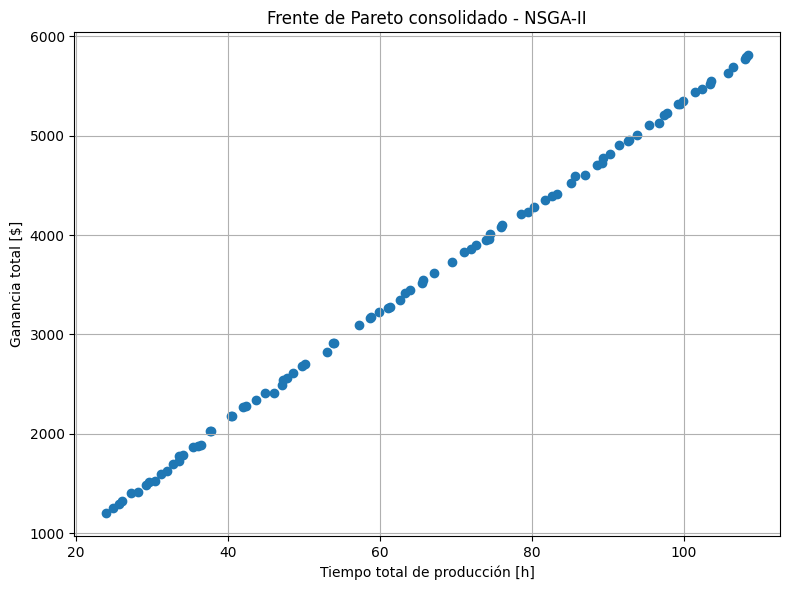

In [6]:
ruta_grafica_nsga2 = CARPETA_RESULTADOS / "frente_pareto_nsga2.png"
guardar_grafica_frente(frente_nsga2_df, "Frente de Pareto consolidado - NSGA-II", ruta_grafica_nsga2)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(frente_nsga2_df["tiempo"], frente_nsga2_df["ganancia"])
ax.set_title("Frente de Pareto consolidado - NSGA-II")
ax.set_xlabel("Tiempo total de producción [h]")
ax.set_ylabel("Ganancia total [$]")
ax.grid(True)
fig.tight_layout()
plt.show()

El frente de NSGA-II muestra las alternativas eficientes encontradas por el algoritmo después de consolidar las cinco corridas. Cada punto representa una solución entera factible; por eso se presenta como dispersión y no como una curva continua obligatoria.

## 9. Frente de Pareto de MOPSO

La gráfica se construye desde el repositorio externo consolidado en memoria.

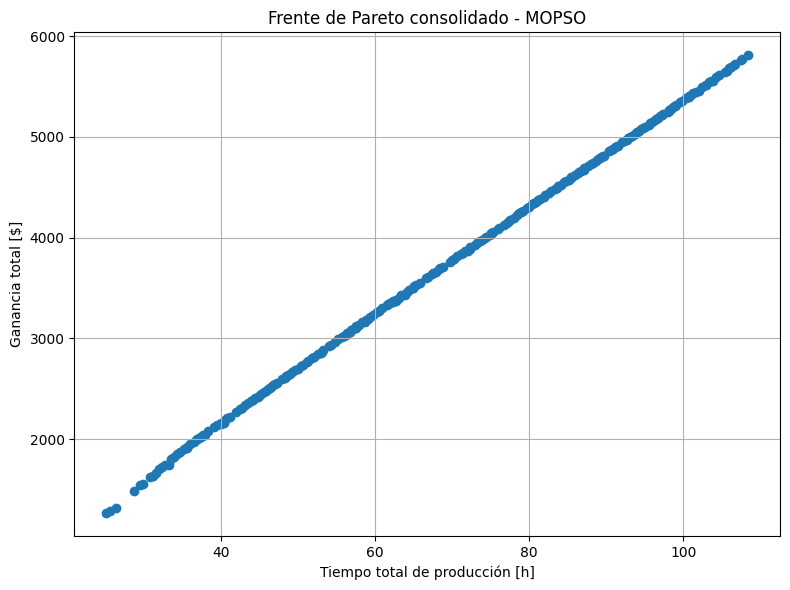

In [7]:
ruta_grafica_mopso = CARPETA_RESULTADOS / "frente_pareto_mopso.png"
guardar_grafica_frente(frente_mopso_df, "Frente de Pareto consolidado - MOPSO", ruta_grafica_mopso)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(frente_mopso_df["tiempo"], frente_mopso_df["ganancia"])
ax.set_title("Frente de Pareto consolidado - MOPSO")
ax.set_xlabel("Tiempo total de producción [h]")
ax.set_ylabel("Ganancia total [$]")
ax.grid(True)
fig.tight_layout()
plt.show()

MOPSO puede presentar un número mayor de puntos porque la consolidación usa los repositorios externos de las cinco corridas, no solo el enjambre final de cada ejecución.

## 10. Comparación de indicadores

Los indicadores agregados se calculan desde la tabla generada durante las corridas.

In [8]:
comparacion_indicadores = (
    tabla_corridas.groupby("metodo")
    .agg(
        porcentaje_promedio=("porcentaje_no_dominadas", "mean"),
        porcentaje_desviacion=("porcentaje_no_dominadas", "std"),
        spacing_promedio=("spacing", "mean"),
        spacing_desviacion=("spacing", "std"),
        tiempo_promedio_s=("tiempo_ejecucion_s", "mean"),
    )
    .reset_index()
)
comparacion_indicadores.to_csv(CARPETA_RESULTADOS / "comparacion_indicadores.csv", index=False, encoding="utf-8-sig")
comparacion_indicadores

,metodo,porcentaje_promedio,porcentaje_desviacion,spacing_promedio,spacing_desviacion,tiempo_promedio_s
0,MOPSO,91.333333,6.497863,0.044829,0.013013,6.770696
1,NSGA-II,100.000000,0.000000,0.024998,0.002935,3.715972


In [9]:
mayor_porcentaje = comparacion_indicadores.loc[comparacion_indicadores["porcentaje_promedio"].idxmax(), "metodo"]
menor_spacing = comparacion_indicadores.loc[comparacion_indicadores["spacing_promedio"].idxmin(), "metodo"]
menor_variabilidad = comparacion_indicadores.loc[comparacion_indicadores["spacing_desviacion"].idxmin(), "metodo"]
menor_tiempo = comparacion_indicadores.loc[comparacion_indicadores["tiempo_promedio_s"].idxmin(), "metodo"]

display(Markdown(
    f"""
La comparación calculada indica que **{mayor_porcentaje}** obtuvo el mayor porcentaje promedio de soluciones no dominadas.  
El menor spacing promedio corresponde a **{menor_spacing}**.  
La menor variabilidad del spacing corresponde a **{menor_variabilidad}**.  
El menor tiempo promedio de ejecución corresponde a **{menor_tiempo}**.
"""
))


La comparación calculada indica que **NSGA-II** obtuvo el mayor porcentaje promedio de soluciones no dominadas.  
El menor spacing promedio corresponde a **NSGA-II**.  
La menor variabilidad del spacing corresponde a **NSGA-II**.  
El menor tiempo promedio de ejecución corresponde a **NSGA-II**.


## 11. Construcción de la matriz de decisión

La matriz se genera desde los frentes calculados en este notebook. Se combinan métodos, se identifican repetidos, se eliminan dominadas de forma cruzada y se agrupan soluciones equivalentes en objetivos.

In [10]:
matriz_decision, estadisticas_decision = construir_matriz_decision_desde_dataframes(frente_nsga2_df, frente_mopso_df)
matriz_decision.to_csv(CARPETA_RESULTADOS / "matriz_decision.csv", index=False, encoding="utf-8-sig")

resumen_decision = pd.DataFrame(
    [{"indicador": clave, "valor": valor} for clave, valor in estadisticas_decision.items()]
)
display(resumen_decision)
matriz_decision.head(10)

,indicador,valor
0,soluciones_nsga2,90
1,soluciones_mopso,254
2,soluciones_totales,344
3,alternativas_unicas,336
4,alternativas_dominadas,62
5,alternativas_no_dominadas,274
6,pares_objetivo_unicos,272


,alternativa,x1,x2,x3,ganancia,tiempo,metodo,alternativas_equivalentes
0,1,30,0,0,1200.0,24.0,NSGA-II,1
1,2,29,0,1,1250.0,24.9,NSGA-II,1
2,3,30,1,0,1265.0,25.2,MOPSO,1
3,4,29,2,0,1290.0,25.6,Ambos,1
4,5,25,5,0,1325.0,26.0,NSGA-II,1
5,6,22,8,0,1400.0,27.2,NSGA-II,1
6,7,33,0,1,1410.0,28.1,NSGA-II,1
7,8,21,10,0,1490.0,28.8,MOPSO,1
8,9,16,14,0,1550.0,29.6,MOPSO,1
9,10,21,11,0,1555.0,30.0,MOPSO,1


## 12. TOPSIS

Se normaliza la ganancia como beneficio y el tiempo como costo. Luego se calcula la matriz ponderada, los ideales positivo y negativo, las distancias y el coeficiente de cercanía.

In [11]:
matriz_normalizada = normalizar_criterios(matriz_decision)
ranking_topsis, ideal_positivo, ideal_negativo = aplicar_topsis(matriz_normalizada)
mejores_topsis = ranking_topsis.sort_values("puntaje_topsis", ascending=False).head(5)
ganadora_topsis = ranking_topsis.loc[ranking_topsis["puntaje_topsis"].idxmax()]

print("Ideal positivo ponderado:", ideal_positivo)
print("Ideal negativo ponderado:", ideal_negativo)
mejores_topsis[
    [
        "ranking_topsis",
        "alternativa",
        "x1",
        "x2",
        "x3",
        "ganancia",
        "tiempo",
        "metodo",
        "ganancia_normalizada",
        "tiempo_normalizado",
        "distancia_ideal_positiva",
        "distancia_ideal_negativa",
        "puntaje_topsis",
    ]
]

Ideal positivo ponderado: [0.5 0.5]
Ideal negativo ponderado: [0. 0.]


,ranking_topsis,alternativa,x1,x2,x3,ganancia,tiempo,metodo,ganancia_normalizada,tiempo_normalizado,distancia_ideal_positiva,distancia_ideal_negativa,puntaje_topsis
95,1,96,0,48,0,3120.0,57.6,MOPSO,0.416486,0.601896,0.353191,0.365971,0.508885
90,2,91,0,47,0,3055.0,56.4,MOPSO,0.402386,0.616114,0.355145,0.367937,0.508846
86,3,87,0,46,0,2990.0,55.2,MOPSO,0.388286,0.630332,0.357368,0.370164,0.508794
83,4,84,0,45,0,2925.0,54.0,MOPSO,0.374187,0.644550,0.359857,0.372646,0.508730
108,5,109,0,50,1,3340.0,61.7,MOPSO,0.464208,0.553318,0.348783,0.361127,0.508694


## 13. Suma ponderada normalizada

Se calcula $S_i = 0.50 r_{iG} + 0.50 r_{iT}$ usando las funciones del módulo `multicriterio.py`.

In [12]:
ranking_multicriterio = aplicar_suma_ponderada(ranking_topsis)
mejores_suma = ranking_multicriterio.sort_values("puntaje_suma_ponderada", ascending=False).head(5)
ganadora_suma = ranking_multicriterio.loc[ranking_multicriterio["puntaje_suma_ponderada"].idxmax()]

mejores_suma[
    [
        "ranking_suma_ponderada",
        "alternativa",
        "x1",
        "x2",
        "x3",
        "ganancia",
        "tiempo",
        "metodo",
        "ganancia_normalizada",
        "tiempo_normalizado",
        "puntaje_suma_ponderada",
    ]
]

,ranking_suma_ponderada,alternativa,x1,x2,x3,ganancia,tiempo,metodo,ganancia_normalizada,tiempo_normalizado,puntaje_suma_ponderada
24,1,25,0,30,0,1950.0,36.0,MOPSO,0.162690,0.857820,0.510255
28,2,29,0,31,0,2015.0,37.2,MOPSO,0.176790,0.843602,0.510196
33,3,34,0,32,0,2080.0,38.4,MOPSO,0.190889,0.829384,0.510137
35,4,36,0,33,0,2145.0,39.6,MOPSO,0.204989,0.815166,0.510078
41,5,42,0,34,0,2210.0,40.8,MOPSO,0.219089,0.800948,0.510018


## 14. Comparación de técnicas multicriterio

Se extraen dinámicamente las alternativas seleccionadas por TOPSIS y suma ponderada normalizada.

In [13]:
seleccionadas = construir_tabla_seleccionadas(ranking_multicriterio)

ranking_multicriterio.to_csv(CARPETA_RESULTADOS / "ranking_multicriterio.csv", index=False, encoding="utf-8-sig")
seleccionadas.to_csv(CARPETA_RESULTADOS / "soluciones_multicriterio.csv", index=False, encoding="utf-8-sig")

seleccionadas

,tecnica,alternativa,x1,x2,x3,ganancia,tiempo,metodo,puntaje
0,TOPSIS,96,0,48,0,3120.0,57.6,MOPSO,0.508885
1,Suma ponderada normalizada,25,0,30,0,1950.0,36.0,MOPSO,0.510255


## 15. Solución final recomendada

Se recomienda la alternativa seleccionada por TOPSIS, de acuerdo con la regla establecida en el informe.

In [14]:
solucion_final = ganadora_topsis
vector_final = solucion_final[["x1", "x2", "x3"]].to_numpy(dtype=int)
recursos_finales = consumo_recursos(vector_final)
factibilidad_final = es_factible(vector_final)

display(Markdown(
    f"""
### Recomendación TOPSIS

- Vector $x$: `{vector_final.tolist()}`
- Escritorios básicos: `{int(solucion_final['x1'])}`
- Escritorios estándar: `{int(solucion_final['x2'])}`
- Escritorios premium: `{int(solucion_final['x3'])}`
- Ganancia: `{float(solucion_final['ganancia']):.6g}`
- Tiempo: `{float(solucion_final['tiempo']):.6g}`
- Método de origen: `{solucion_final['metodo']}`
- Puntaje TOPSIS: `{float(solucion_final['puntaje_topsis']):.6f}`
- Factible según `problema.py`: `{factibilidad_final}`
"""
))

nombres_recursos = ["Lámina", "Corte", "Soldadura", "Empaque"]
tabla_recursos_final = pd.DataFrame(
    {
        "recurso": nombres_recursos,
        "consumo": recursos_finales,
        "disponibilidad": DISPONIBILIDADES,
        "margen_restante": DISPONIBILIDADES - recursos_finales,
    }
)
tabla_recursos_final


### Recomendación TOPSIS

- Vector $x$: `[0, 48, 0]`
- Escritorios básicos: `0`
- Escritorios estándar: `48`
- Escritorios premium: `0`
- Ganancia: `3120`
- Tiempo: `57.6`
- Método de origen: `MOPSO`
- Puntaje TOPSIS: `0.508885`
- Factible según `problema.py`: `True`


,recurso,consumo,disponibilidad,margen_restante
0,Lámina,96.0,180.0,84.0
1,Corte,21.6,45.0,23.4
2,Soldadura,28.8,65.0,36.2
3,Empaque,7.2,18.0,10.8


## 16. Conclusiones

Las conclusiones se construyen dinámicamente desde los resultados calculados.

In [15]:
tecnica_topsis = seleccionadas.loc[seleccionadas["tecnica"].eq("TOPSIS")].iloc[0]
tecnica_suma = seleccionadas.loc[seleccionadas["tecnica"].eq("Suma ponderada normalizada")].iloc[0]

metodo_mas_puntos = pd.DataFrame(
    [
        {"metodo": "NSGA-II", "puntos": len(frente_nsga2_df)},
        {"metodo": "MOPSO", "puntos": len(frente_mopso_df)},
    ]
).sort_values("puntos", ascending=False).iloc[0]

display(Markdown(
    f"""
- En la comparación de indicadores, **{mayor_porcentaje}** alcanzó el mayor porcentaje promedio de soluciones no dominadas, **{menor_spacing}** obtuvo el menor spacing promedio y **{menor_tiempo}** tuvo el menor tiempo promedio de ejecución.
- El repositorio externo de MOPSO aportó un frente consolidado con **{int(metodo_mas_puntos['puntos'])}** puntos para **{metodo_mas_puntos['metodo']}**, lo que evidencia su papel en conservar alternativas no dominadas a lo largo de las iteraciones.
- TOPSIS seleccionó la alternativa **{int(tecnica_topsis['alternativa'])}** con vector **{[int(tecnica_topsis['x1']), int(tecnica_topsis['x2']), int(tecnica_topsis['x3'])]}** y puntaje **{float(tecnica_topsis['puntaje']):.6f}**.
- La suma ponderada normalizada seleccionó la alternativa **{int(tecnica_suma['alternativa'])}** con vector **{[int(tecnica_suma['x1']), int(tecnica_suma['x2']), int(tecnica_suma['x3'])]}** y puntaje **{float(tecnica_suma['puntaje']):.6f}**.
- La solución final recomendada es la de TOPSIS, verificada como factible contra las restricciones del modelo mediante `problema.py`.
"""
))


- En la comparación de indicadores, **NSGA-II** alcanzó el mayor porcentaje promedio de soluciones no dominadas, **NSGA-II** obtuvo el menor spacing promedio y **NSGA-II** tuvo el menor tiempo promedio de ejecución.
- El repositorio externo de MOPSO aportó un frente consolidado con **254** puntos para **MOPSO**, lo que evidencia su papel en conservar alternativas no dominadas a lo largo de las iteraciones.
- TOPSIS seleccionó la alternativa **96** con vector **[0, 48, 0]** y puntaje **0.508885**.
- La suma ponderada normalizada seleccionó la alternativa **25** con vector **[0, 30, 0]** y puntaje **0.510255**.
- La solución final recomendada es la de TOPSIS, verificada como factible contra las restricciones del modelo mediante `problema.py`.


## 17. Referencias

[1] Universidad Nacional de Colombia, *Material del curso Técnicas de Optimización 2026-I*, 2026.

[2] X. Liu, H. Guo, H. Chen, Y. Wu y D. Yu, “An Improved NSGA-II-TOPSIS Integrated Framework for Multi-Objective Optimization of Electric Vehicle Charging Station Siting,” *Sustainability*, vol. 18, art. 668, 2026, doi: 10.3390/su18020668.

[3] A. Ruiz-Vélez, J. García, J. Alcalá y V. Yepes, “Sustainable Road Infrastructure Decision-Making: Custom NSGA-II with Repair Operators for Multi-Objective Optimization,” *Mathematics*, vol. 12, no. 5, art. 730, 2024, doi: 10.3390/math12050730.

## 18. Resumen de archivos generados

La carpeta `resultados/` se inspecciona con Python para listar los archivos realmente disponibles después de la ejecución.

In [16]:
archivos_generados = []
for ruta in sorted(CARPETA_RESULTADOS.iterdir()):
    if ruta.is_file():
        archivos_generados.append(
            {
                "nombre": ruta.name,
                "tipo": ruta.suffix.lstrip(".") or "sin_extension",
                "tamano_kb": ruta.stat().st_size / 1024,
            }
        )

pd.DataFrame(archivos_generados)

,nombre,tipo,tamano_kb
0,comparacion_indicadores.csv,csv,0.281250
1,frente_pareto_mopso.csv,csv,6.039062
2,frente_pareto_mopso.png,png,109.239258
3,frente_pareto_nsga2.csv,csv,2.085938
4,frente_pareto_nsga2.png,png,114.678711
5,indicadores_corridas.csv,csv,0.839844
6,matriz_decision.csv,csv,9.589844
7,ranking_multicriterio.csv,csv,42.041016
8,soluciones_multicriterio.csv,csv,0.203125
